# Utilizando a API do Google Gemini

Já vimos aqui no blog como escrever programas em Python integrados o **ChatGPT**. 
Neste artigo, veremos como fazer o mesmo, porém integrando com o **Gemini**, da Google.

Apenas lembrando que não vamos usar a interface de usuário do ChatGPT. Todo o acesso será feito
por meio do código de um programa Python, usando uma **API** (Interface de Programação de Aplicações) própria do Gemini.

E o que podemos fazer assim? Podemos criar programas que usam o ChatGPT adaptado ao contexto específico da sua aplicação. Por exemplo:
- Você pode dar, ao ChatGPT, acesso a dados específicos do usuário, como documentos ou atividades agendadas.
- Você pode personalizar o ChatGPT para disparar código Python para realizar cálculos complexos ou outras ações.
- O ChatGPT pode fazer resumos, classificar textos, ou fazer outro tipo de raciocínio em linguagem natural.

Enfim, você pode mesclar a capacidade de linguagem e raciocínio do ChatGPT com a capacidade de programação Python tradicional para criar programas inovadores!

Neste documento, você saberá como acessar e utilizar o **Google Gemini** para esse fim.

## 1 - Configurações Iniciais

### Pre requisitos

1 - Python 3.9 ou superior.

2 - Uma instalação de jupyter para executar o notebook.

3 - Possuir a seguinte biblioteca instalada (google-generativeai)

```bash
pip install google-generativeai
```


O seguinte modulo ira instalar a biblioteca **google-generativeai** caso a mesma  não esteja instalada.

### Obtendo uma chave para sua API

1 - Acesse o seguinte site: [Google API Key.](https://aistudio.google.com/app/apikey?hl=pt-br)

2 - Caso ainda não esteja logado, faça o login utilizando sua conta Google e aceite os termos de serviço.

3 - Clique no botão **Criar chave de API** para criar uma chave para um novo projeto.

4 - Nesse momento será exibido uma mensagem com os termos de serviço, basta clicar em **OK** para prosseguir.

5 - Uma caixa contendo a opção de **Criar uma chave de API em um novo projeto**, Basta clicar para prosseguir.

6 - Parabéns sua chave de API ja foi gerada basta clicar em copiar para acessá-la.

---

OBS: A chave de API é um elemento crítico para acessar os serviços fornecidos pela Google API. Essa chave funciona como uma senha que autentica suas solicitações e garante que você tenha permissão para acessar os recursos.

Por esse motivo, deve-se prestar muita atenção para que a mesma não fique disponível publicamente.

---

### Armazenando uma chave de API

Por esse motivo você vai precisar salvar com o nome GOOGLE_API_KEY em um arquivo `.env` e carregar este arquivo com o módulo `dotenv`.

In [1]:
from dotenv import load_dotenv, find_dotenv
import google.generativeai as gemini
import google.generativeai.client as client
import os

c:\Faculdade\Repositorios\Repositorio_Academico_Multidisciplinar\Extencao\Post_01\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Primeiramente devemos garantir que a chave da API não fique disponível publicamente, para isso devemos criar um arquivo chamado .env

1 - Crie um arquivvo chamado .env

2 - O preencha da seguinte maneira (GOOGLE_API_KEY='Sua chave da API'.
)

3 - Lembrar de substituir o trecho **Sua chave da API** pela sua chave.

# Explicação do Código

Este notebook explica o funcionamento de três funções escritas em Python para manipulação de uma chave API, utilizando a biblioteca `python-dotenv` para lidar com variáveis de ambiente em um arquivo `.env`.

### Explicação das seguintes funções:

**carrega_chave:**
 Objetivo: Esta função carrega a chave API armazenada no arquivo .env e configura a biblioteca gemini com essa chave.

**verifica_chave:**
 Objetivo: Esta função verifica a existência do arquivo .env no sistema.


In [2]:
def carrega_chave(): # Carrega uma chave do arquivo .env
    _ = load_dotenv(find_dotenv())
    chave = os.getenv("GOOGLE_API_KEY")
    gemini.configure(api_key=os.getenv('GOOGLE_API_KEY'))

    print(f"Chave API carregada com sucesso!")
    return chave

def verifica_chave(): # Verifica a existência de um arquivo .env 
    return find_dotenv()


In [3]:
chave = carrega_chave()

Chave API carregada com sucesso!


Parabéns, agora sua chave já está carregada!

## 2 - Utilizando o serviço (Textual)

### Verificando modelos

Primeiramente devemos verificar quais são todos os modelos disponíveis para utilização dsiponibilizados pelo **Google Gemini**.

Para isso basta utilizar o seguinte comando parea receber a lista com os modelos existentes.


In [29]:
modelos = client.get_default_model_client().list_models()

Agora a variável **modelos** contém uma lista contendo todos os modelos existentes.

Para listar apenas os modelos generativos, utilize um loop `for` para filtrar os dados em que `model.supported_generation_methods` seja igual a `'generateContent'` como demonstra o código a seguir.

In [30]:
for model in modelos:
    if 'generateContent' in model.supported_generation_methods:
        print(model.name)


models/gemini-1.0-pro-latest
models/gemini-1.0-pro
models/gemini-pro
models/gemini-1.0-pro-001
models/gemini-1.0-pro-vision-latest
models/gemini-pro-vision
models/gemini-1.5-pro-latest
models/gemini-1.5-pro-001
models/gemini-1.5-pro
models/gemini-1.5-pro-exp-0801
models/gemini-1.5-flash-latest
models/gemini-1.5-flash-001
models/gemini-1.5-flash
models/gemini-1.5-flash-001-tuning


---

Principalmente podemos trabalhar com os modelos mais atualizados sendo eles:

gemini-1.5-flash - Sendo o melhor custo benefício. **Será utilizado nesta publicação**

gemini-1.5-pro - Sendo o melhor modelo.

Como chegam a essas conclusões estará disponível em uma publicação futura.

### Testes

Caso queira testar a capacidade de todas as versões possíveis, você pode ainda conectado a sua conta entrar em [Google AI Studio](https://aistudio.google.com/) e testar!

Nesse ambiente você pode selecionar e utilizar das mais diferentes versões existentes. 

Valendo também citar que a versão 2 do gemini em formato de **Preview**

### Primeiros passos com o modelo


Ao final desta publicação existirá uma área própria para comparação entre alguns modelos listados nessa lista.


In [4]:
# Carregando o modelo
model = gemini.GenerativeModel('gemini-1.5-flash')

Nesse caso vou solicitar **"faça um resumo em uma linha de:"** a função **statistics.median_high** do python

A fonte desse trecho é da documentação oficial do python: [Documentação do Python: statistics.median_high](https://docs.python.org/pt-br/3/library/statistics.html#statistics.median_high)


In [32]:
# Recebendo nossa primeira mensagem via código
resposta = model.generate_content("faça um resumo em uma linha de: statistics.median_high(data) Retorna a mediana superior de dados numéricos. Se data for vazio, a exceção StatisticsError é levantada. data pode ser uma sequência ou um iterável. A mediana superior sempre é um membro do conjunto de dados. Quando o número de elementos for ímpar, o valor intermediário é retornado. Se houver um número par de elementos, o maior entre os dois valores centrais é retornado.")

Algumas informações da resposta


In [33]:
print(resposta.text) # Resposta textual
print(resposta.usage_metadata) # Informações como número de tokens usados

`statistics.median_high(data)` retorna o maior dos dois valores médios em um conjunto de dados, ou o único valor médio se o número de elementos for ímpar. 

prompt_token_count: 102
candidates_token_count: 37
total_token_count: 139



Logo nesse podemos ja realizar a utilização desse modelo dentro de uma aplicação, exemplo:

Imagine que tenhamos um app que recomenda receitas para o usuário baseando-se nos ingredientes possuídos pelo usuário.

In [34]:
# Pegando o input do suario (simulando uma aplicação).
ingredientes = input("Liste os ingredientes que você possui? ")

Exemplo de lista de ingredientes: ovos, farinha de trigo, leite, açúcar, sal, manteiga

Nesse exemplo deveremos utilizar um pouco da noção de prompt engineering.
(Atualizar com o link da post falando sobre prompt engineering)   

In [35]:
# Forma junto com a variavel ingredientes uma entrada adequada para a nossa proposta
texto_final = (f"Com os seguintes ingredientes: {ingredientes}, escreva uma receita completa que utilize esses e apenas esses ingredientes.")

In [36]:
# Gera a resposta que estamos buscando
resposta = model.generate_content(texto_final)

In [37]:
print(resposta.text) # Resposta textual
print(resposta.usage_metadata) # Informações como número de tokens usados

## Bolo Simples de Leite

**Ingredientes:**

* 3 ovos grandes em temperatura ambiente
* 1 xícara (120g) de manteiga sem sal, derretida e levemente resfriada
* 1 xícara (200g) de açúcar granulado
* 2 xícaras (250g) de farinha de trigo
* 1 colher de chá de fermento em pó
* 1/2 colher de chá de bicarbonato de sódio
* 1/2 colher de chá de sal
* 1 xícara (240ml) de leite integral

**Instruções:**

1. Pré-aqueça o forno a 180°C e unte e enfarinhe uma forma redonda com furo no centro de 23cm de diâmetro.
2. Em uma tigela grande, bata os ovos com a manteiga derretida e o açúcar até obter um creme claro e fofo.
3. Em outra tigela, misture a farinha, o fermento, o bicarbonato e o sal.
4. Adicione gradualmente os ingredientes secos à tigela com os ovos, alternando com o leite, começando e terminando com os ingredientes secos. Misture até incorporar todos os ingredientes, mas não bata demais.
5. Despeje a massa na forma preparada e asse por 30 a 35 minutos, ou até que um palito inserido no centro 

Como fica perceptível a receita foi impressa de modo completamente geracional, parabéns!

## 3 - Utilizando imagens

Agora vamos utilizar o serviço utilizando como entrada uma imagem.

Primeiramente devemos carregar uma imagem em uma variável, para isso vou utilizar a biblioteca PLT a imagem está armazenada em "Imagens\animal.jpg"  a partir do diretório que esse script está escrito.

In [1]:
from IPython.display import Image as IPImage
import PIL.Image

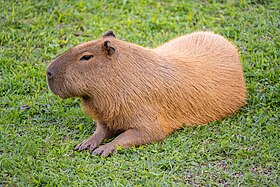

In [15]:
img = PIL.Image.open(r'Imagens\animal.jpg')
img

A partir desse momento já é possível utilizar essa imagem como entrada para busca de resposta.

In [16]:
resposta = model.generate_content(img)
print(resposta.text)

This is a capybara. It is the largest rodent in the world and is native to South America. Capybaras are semi-aquatic and are often found near bodies of water. They are herbivores and are known for their docile nature.


Caso queira-mos enviar uma imagem e um texto para alguma finalidade específica, por exemplo: 

Identificar um animal em uma imagem. (uma capivara no exemplo da imagem citada)

Basta que enviemos uma lista **[A, B]** contendo:

A - Texto de entrada nesse caso "Identifique esse o animal nessa imagem".

B - Variável contendo a imagem.

In [17]:
resposta = model.generate_content(["Identifique esse o animal nessa imagem", img])

In [18]:
print(resposta.text)

Esse é um capivara.  



## 4 - Utilizando o conceito de chat

Quando se pensa em uma interação contínua com um usuário, vale a pena se utilizar da função chat (Que armazena e utiliza o histórico de mensagens trocadas).

In [5]:
chat = model.start_chat(history=[])
chat # agora o chat está armazenado nesta variável

ChatSession(
    model=genai.GenerativeModel(
        model_name='models/gemini-1.5-flash',
        generation_config={},
        safety_settings={},
        tools=None,
        system_instruction=None,
        cached_content=None
    ),
    history=[]
)

In [6]:
resposta = chat.send_message("Escreva uma linha de uma historia sobre o cachorro bernardo")
print(resposta.text)

A cauda de Bernardo, geralmente um borrão feliz, caiu ao chão quando ele percebeu que o bebê estava desaparecido. 



Agora é possível ver todo o histórico de mensagens usando o seguinte comando

In [7]:
chat.history

[parts {
   text: "Escreva uma linha de uma historia sobre o cachorro bernardo"
 }
 role: "user",
 parts {
   text: "A cauda de Bernardo, geralmente um borrão feliz, caiu ao chão quando ele percebeu que o bebê estava desaparecido. \n"
 }
 role: "model"]

In [8]:
resposta = chat.send_message("Troque o nome de bernardo para severino")
print(resposta.text)

A cauda de Severino, geralmente um borrão feliz, caiu ao chão quando ele percebeu que o bebê estava desaparecido. 




A metodologia acima garante com que haja uma continuidade no envio de mensagens para o modelo, permitindo com que alterações em determinadas partes sejam possíveis. (como demonstrado pela troca do nome do cachorro bernardo).

In [9]:
for mensagem in chat.history:
  print(f'{mensagem.role}: {mensagem.parts[0].text}')

user: Escreva uma linha de uma historia sobre o cachorro bernardo
model: A cauda de Bernardo, geralmente um borrão feliz, caiu ao chão quando ele percebeu que o bebê estava desaparecido. 

user: Troque o nome de bernardo para severino
model: A cauda de Severino, geralmente um borrão feliz, caiu ao chão quando ele percebeu que o bebê estava desaparecido. 



Parabéns, agora você compreende como o até mesmo o chat funciona, mas vamos é necessário realizar uma comparação entre alguns modelos existentes no **google Gemini**.

## Referências

Documentação oficial da API do Gemini: [Documentação](https://ai.google.dev/gemini-api/docs?hl=pt-br)

Documentação official do python na função statistics.median_high: [Documentação do Python: statistics.median_high](https://docs.python.org/pt-br/3/library/statistics.html#statistics.median_high)

Imagem utilizada: [Imagems](https://www.istockphoto.com/br/fotos/capivara)
